🧩 Building high-resolution mosaic...
✅ Mosaic built successfully. Launching interactive viewer...


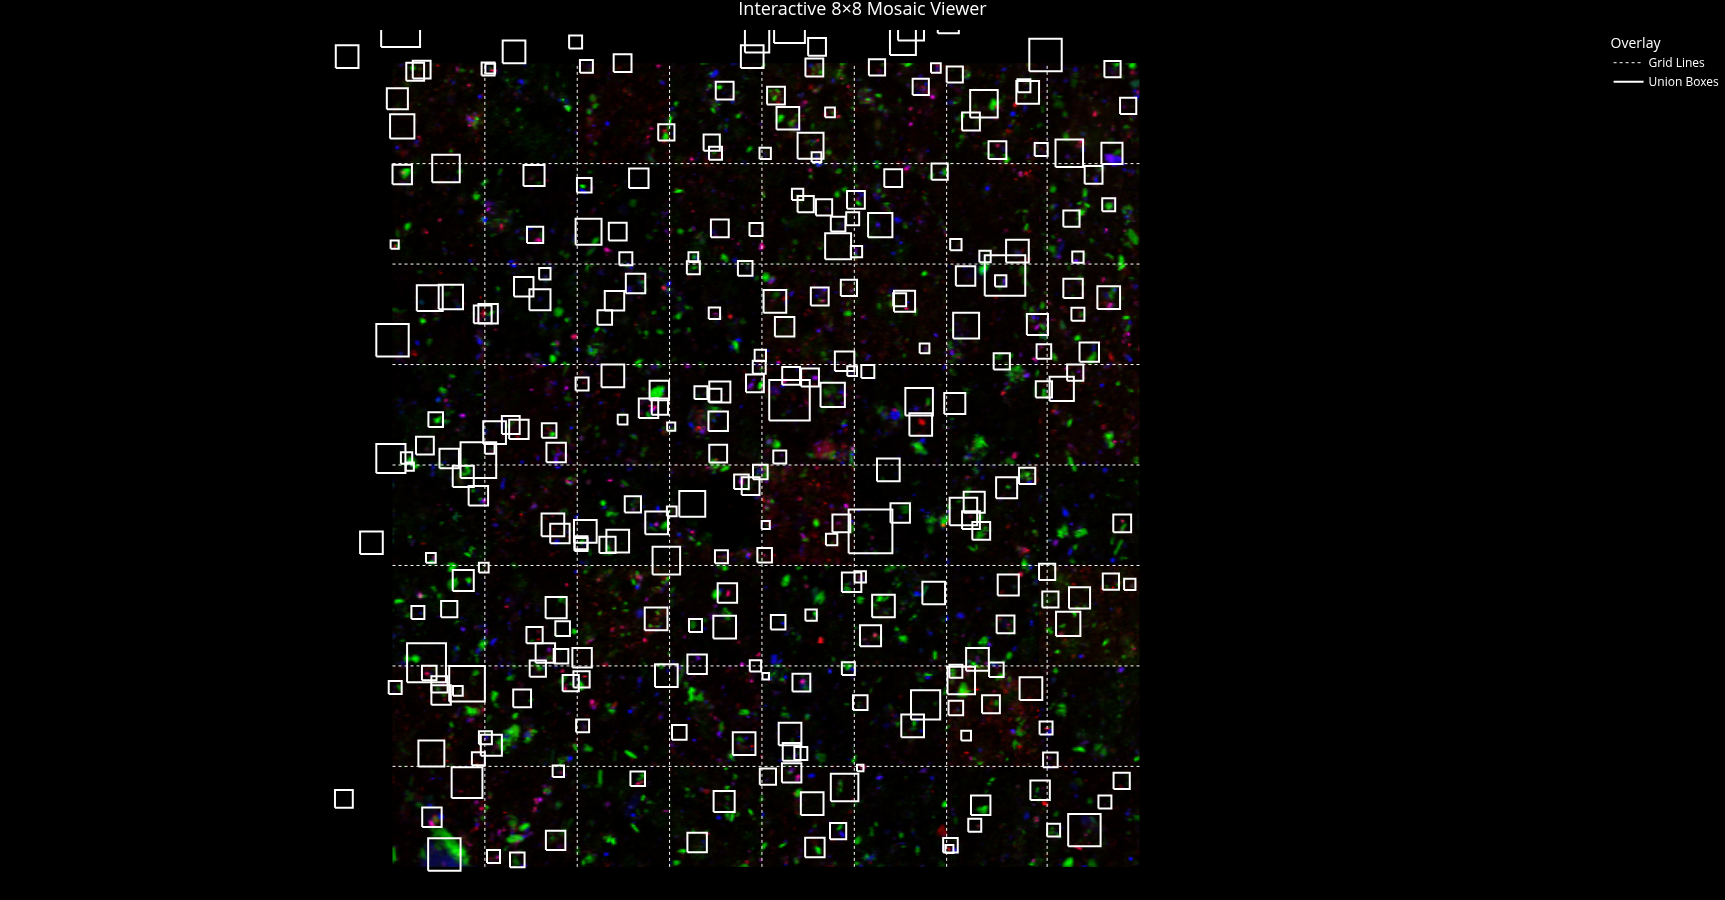

In [18]:
#!/usr/bin/env python3
"""
plotly_mosaic_viewer.py
Generates an 8x8 stitched RGB mosaic from given scan folders
and displays it interactively using Plotly (zoomable, pannable,
with toggleable grid lines and union boxes via legend).
"""

import os
import numpy as np
from PIL import Image
import plotly.graph_objects as go
import plotly.io as pio
import json

# === CONFIG ===
base_root = "/home/codingcarlos/Desktop/Data/Beamline_Data/Automap_2025Q3/all_xrf"
info_path = "/home/codingcarlos/Desktop/Data/Beamline_Data/Automap_2025Q3/data/user_macros"

scan_ids = [
    367582, 367589, 367592, 367596, 367600, 367609, 367614, 367622,
    367630, 367634, 367638, 367641, 367646, 367653, 367658, 367663,
    367667, 367671, 367675, 367680, 367686, 367692, 367698, 367703,
    367710, 367715, 367720, 367726, 367733, 367741, 367744, 367748,
    367754, 367760, 367767, 367772, 367780, 367786, 367789, 367795,
    367798, 367803, 367807, 367813, 367816, 367819, 367825, 367830,
    367837, 367846, 367851, 367857, 367862, 367870, 367873, 367880,
    367885, 367890, 367897, 367899, 367903, 367910, 367915, 367921
]

elements = {
    "R": "detsum_Cu_K_norm.tiff",
    "G": "detsum_Ca_K_norm.tiff",
    "B": "detsum_Fe_K_norm.tiff"
}

# === HELPERS ===
def normalize(arr):
    arr = arr - np.min(arr)
    if np.max(arr) > 0:
        arr = arr / np.max(arr)
    return (arr * 255).astype(np.uint8)

def make_rgb_image(scan_folder):
    channels = {}
    for ch, fname in elements.items():
        path = os.path.join(base_root, scan_folder, fname)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing: {path}")
        arr = np.array(Image.open(path).convert("F"))
        channels[ch] = normalize(arr)
    rgb = np.stack([channels["R"], channels["G"], channels["B"]], axis=-1)
    return Image.fromarray(rgb, mode="RGB")

def stitch_mosaic(scan_ids, grid_size=(8, 8), shift_x=5):
    rows, cols = grid_size
    tile_imgs = []
    tile_size = None
    for sid in scan_ids:
        folder = f"output_tiff_scan2D_{sid}"
        try:
            img = make_rgb_image(folder)
        except FileNotFoundError as e:
            print(e)
            img = Image.new("RGB", (512, 512), (0, 0, 0))
        if tile_size is None:
            tile_size = img.size
        tile_imgs.append(img.resize(tile_size))

    tile_w, tile_h = tile_size
    mosaic_w = cols * tile_w - (cols - 1) * shift_x
    mosaic_h = rows * tile_h
    mosaic = Image.new("RGB", (mosaic_w, mosaic_h))
    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            if idx >= len(tile_imgs):
                break
            x = j * tile_w - j * shift_x
            y = i * tile_h
            mosaic.paste(tile_imgs[idx], (x, y))
    return mosaic, tile_size

# === PLOTLY DISPLAY ===
def show_plotly_mosaic(mosaic, scan_ids, tile_size, grid_size=(8, 8), shift_x=5):
    img_np = np.array(mosaic)
    h, w, _ = img_np.shape
    n_rows, n_cols = grid_size
    tile_w, tile_h = tile_size

    fig = go.Figure()

    # Add mosaic image
    fig.add_layout_image(
        dict(
            source=Image.fromarray(img_np),
            xref="x", yref="y",
            x=0, y=h,
            sizex=w, sizey=h,
            sizing="stretch",
            layer="below"
        )
    )

    # --- GRID LINES TRACE (vertical lines account for shift_x) ---
    x_lines, y_lines = [], []

    # start from the rightmost column
    for i in range(1, n_cols):
        # Rightmost line extends full width
        if i == n_cols - 1:
            x_pos = i * tile_w - (i-1) * shift_x
        else:
            x_pos = i * tile_w - i * shift_x
        x_lines += [x_pos, x_pos, None]
        y_lines += [0, h, None]

    for j in range(1, n_rows):
        y_lines += [j * tile_h, j * tile_h, None]
        x_lines += [0, w, None]

    fig.add_trace(go.Scatter(
        x=x_lines, y=y_lines,
        mode="lines",
        line=dict(color="white", width=1, dash="dot"),
        name="Grid Lines",
        visible=True
    ))

    # --- UNION BOXES TRACE ---
    box_x, box_y = [], []
    hover_texts = []

    for idx, scan_id in enumerate(scan_ids):
        union_json_path = os.path.join(info_path, f"automap_{scan_id}", "unions_output.json")
        if not os.path.exists(union_json_path):
            continue
        with open(union_json_path, "r") as f:
            unions = json.load(f)

        row = idx // n_cols
        col = idx % n_cols

        # Top-left origin for tiles in mosaic
        y_offset = h - (row + 1) * tile_h
        x_offset = col * tile_w - col * shift_x

        for key, obj in unions.items():
            cx, cy = obj["image_center"]
            length = obj["image_length"]

            # Flip Y axis only inside the tile
            x0 = x_offset + cx - length / 2
            y0 = y_offset + (tile_h - cy) - length / 2
            x1 = x0 + length
            y1 = y0 + length

            # rectangle as closed polygon
            box_x += [x0, x1, x1, x0, x0, None]
            box_y += [y0, y0, y1, y1, y0, None]
            hover_texts += [f"ID: {scan_id}<br>Center: ({cx:.1f}, {cy:.1f})"]*6

    fig.add_trace(go.Scatter(
        x=box_x, y=box_y,
        mode="lines",
        line=dict(color="white", width=2),
        name="Union Boxes",
        text=hover_texts,
        hoverinfo="text",
        visible=True
    ))

    # Axes config
    fig.update_xaxes(visible=False, range=[0, w])
    fig.update_yaxes(visible=False, range=[0, h], scaleanchor="x")

    # Layout
    fig.update_layout(
        width=900, height=900,
        margin=dict(l=0,r=0,t=30,b=0),
        paper_bgcolor="black",
        plot_bgcolor="black",
        showlegend=True,
        legend=dict(title="Overlay", x=1.05, y=1, bgcolor="rgba(0,0,0,0.5)", font=dict(color="white")),
        title=dict(text="Interactive 8×8 Mosaic Viewer", x=0.5, xanchor="center", font=dict(size=18,color="white"))
    )

    pio.show(fig)

# === MAIN ===
if __name__ == "__main__":
    print("🧩 Building high-resolution mosaic...")
    mosaic, tile_size = stitch_mosaic(scan_ids, grid_size=(8, 8), shift_x=5)
    print("✅ Mosaic built successfully. Launching interactive viewer...")
    show_plotly_mosaic(mosaic, scan_ids, tile_size, grid_size=(8, 8), shift_x=5)


In [ ]:
check the fine scans if they match the location and see how many total boxes there are in json vs actual 